In [95]:
#importing libraries 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("StudentsPerformance.csv")
df["Result"] = df["math score"].apply(lambda x: 1 if x >= 50 else 0)
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score   id  \
0                    none          72             72             74  0.0   
1               completed          69             90             88  1.0   
2                    none          90             95             93  2.0   
3                    none          47             57             44  3.0   
4                    none          76             78             75  4.0   

   Result  
0       1  
1       1  
2       1  
3       0  
4       1  


In [96]:
# Feature Selection

x = df[["reading score","writing score"]]
y = df["Result"]

In [97]:
#EDA 

print(df.head())
print(df.info())
print(df.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score   id  \
0                    none          72             72             74  0.0   
1               completed          69             90             88  1.0   
2                    none          90             95             93  2.0   
3                    none          47             57             44  3.0   
4                    none          76             78             75  4.0   

   Result  
0       1  
1       1  
2       1  
3       0  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [98]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
    )

In [99]:
# Scalling

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [100]:
# Training the model

model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [101]:
predic = model.predict(x_test)
print(predic)

[1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [102]:
# Evaluation

print("Accuracy Score:",accuracy_score(y_test,predic))
print("Confusion Score:\n",confusion_matrix(y_test,predic))

Accuracy Score: 0.855
Confusion Score:
 [[ 14  20]
 [  9 157]]


In [103]:
#train and test accuracy

train_Acc = accuracy_score(y_train, model.predict(x_train))
test_acc = accuracy_score(y_test, predic)

print("Train Accuracy:", train_Acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9075
Test Accuracy: 0.855


In [104]:
# Decision Tree Classifier

tree = DecisionTreeClassifier()
tree.fit(x_train,y_train)

tree_predic = tree.predict(x_test)
print("Decision Tree Accuracy Score:",accuracy_score(y_test,tree_predic))
print("Decision Tree Confusion Score:\n",confusion_matrix(y_test,tree_predic))

Decision Tree Accuracy Score: 0.805
Decision Tree Confusion Score:
 [[ 16  18]
 [ 21 145]]


In [105]:
# Random Forest Classifier

rf = RandomForestClassifier()
rf.fit(x_train,y_train)

rf_predic = rf.predict(x_test)
print("Random Forest Accuracy Score:",accuracy_score(y_test,rf_predic))
print("Random Forest Confusion Score:\n",confusion_matrix(y_test,rf_predic))

Random Forest Accuracy Score: 0.83
Random Forest Confusion Score:
 [[ 13  21]
 [ 13 153]]


In [106]:
# Comparision 

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, predic),
        accuracy_score(y_test, tree_predic),
        accuracy_score(y_test, rf_predic)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.855
1        Decision Tree     0.805
2        Random Forest     0.830


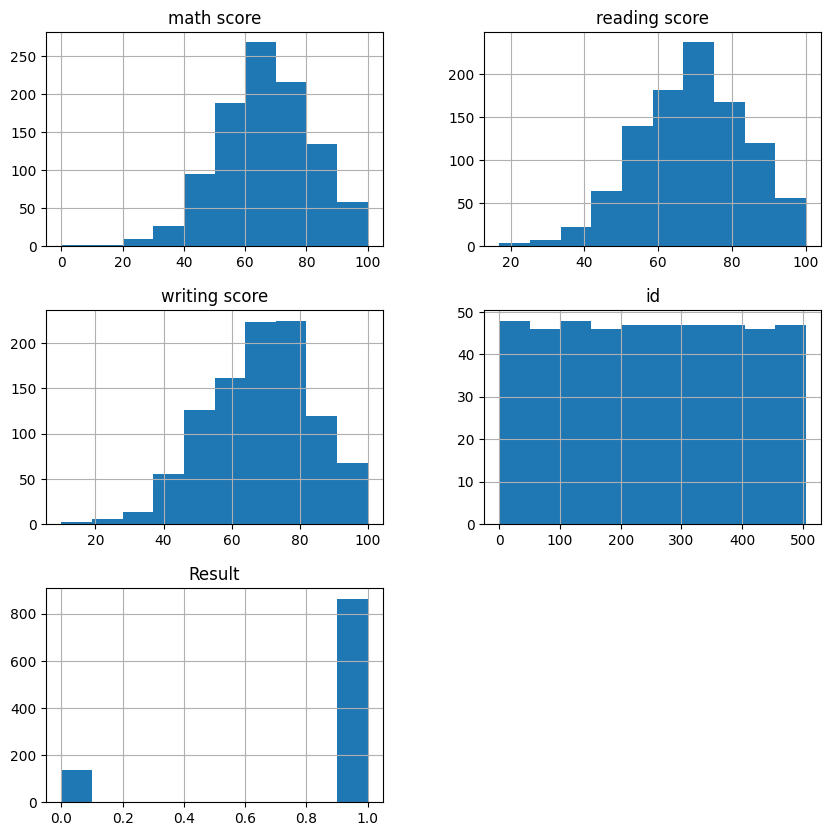

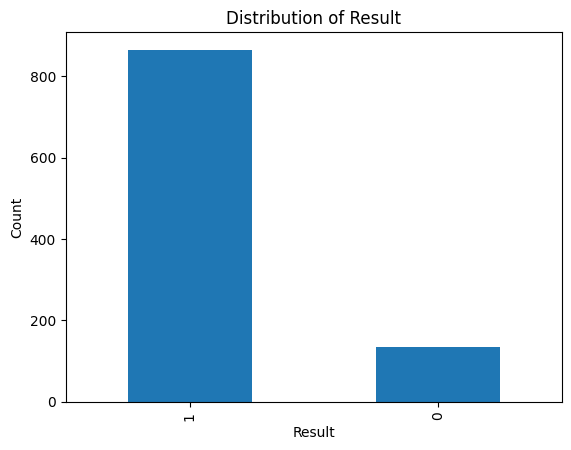

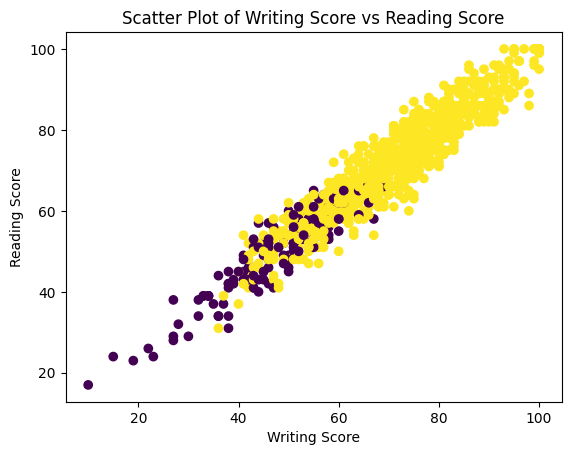

In [107]:
#Histogram of Scores

df.hist(figsize=(10,10))
plt.show()

# Class Distribution

df["Result"].value_counts().plot(kind="bar")
plt.xlabel("Result")
plt.ylabel("Count")
plt.title("Distribution of Result")
plt.show()

# Scatter Plot of Writing Score vs Reading Score

plt.scatter(x["writing score"], x["reading score"], c=y)
plt.xlabel("Writing Score")
plt.ylabel("Reading Score")
plt.title("Scatter Plot of Writing Score vs Reading Score")
plt.show()

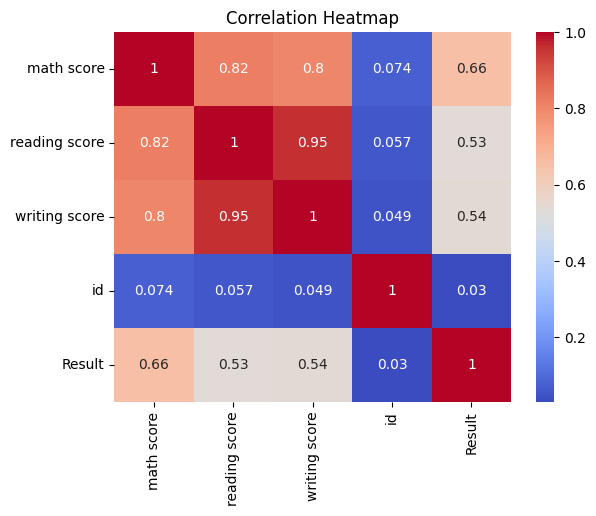

In [108]:
# Correlation Heatmap

corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()